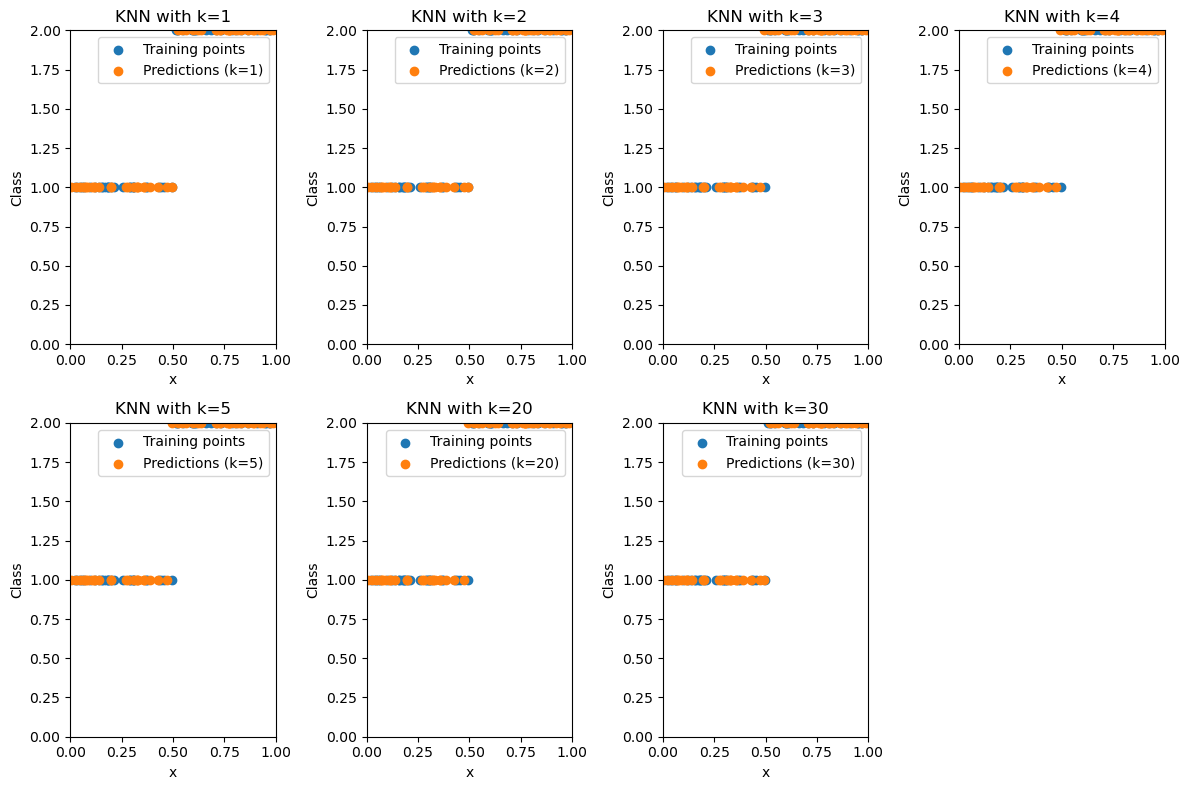

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Generate the data
np.random.seed(42)  # For reproducibility

X_train = np.random.rand(50, 1)  # Training features
y_train = np.array([1 if x <= 0.5 else 2 for x in X_train.ravel()])  # Labels

X_test = np.random.rand(50, 1)  # Test data

# Step 2: Function for KNN classification
def classify_knn(X_train, y_train, X_test, k_values):
    predictions = {}  # Store results

    # Loop over k values
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)        # Train model
        y_pred = knn.predict(X_test)     # Predict
        predictions[k] = y_pred          # Store results

    return predictions

# Step 3: Run KNN for different k values
k_values = [1, 2, 3, 4, 5, 20, 30]
predictions = classify_knn(X_train, y_train, X_test, k_values)

# Step 4: Plot results
plt.figure(figsize=(12, 8))

for i, k in enumerate(k_values, 1):
    plt.subplot(2, 4, i)

    # Training points
    plt.scatter(X_train, y_train, label='Training points')

    # Predicted points
    plt.scatter(X_test, predictions[k], label=f'Predictions (k={k})')

    plt.title(f'KNN with k={k}')
    plt.xlabel('x')
    plt.ylabel('Class')
    plt.xlim(0, 1)
    plt.ylim(0, 2)
    plt.legend()

plt.tight_layout()
plt.show()

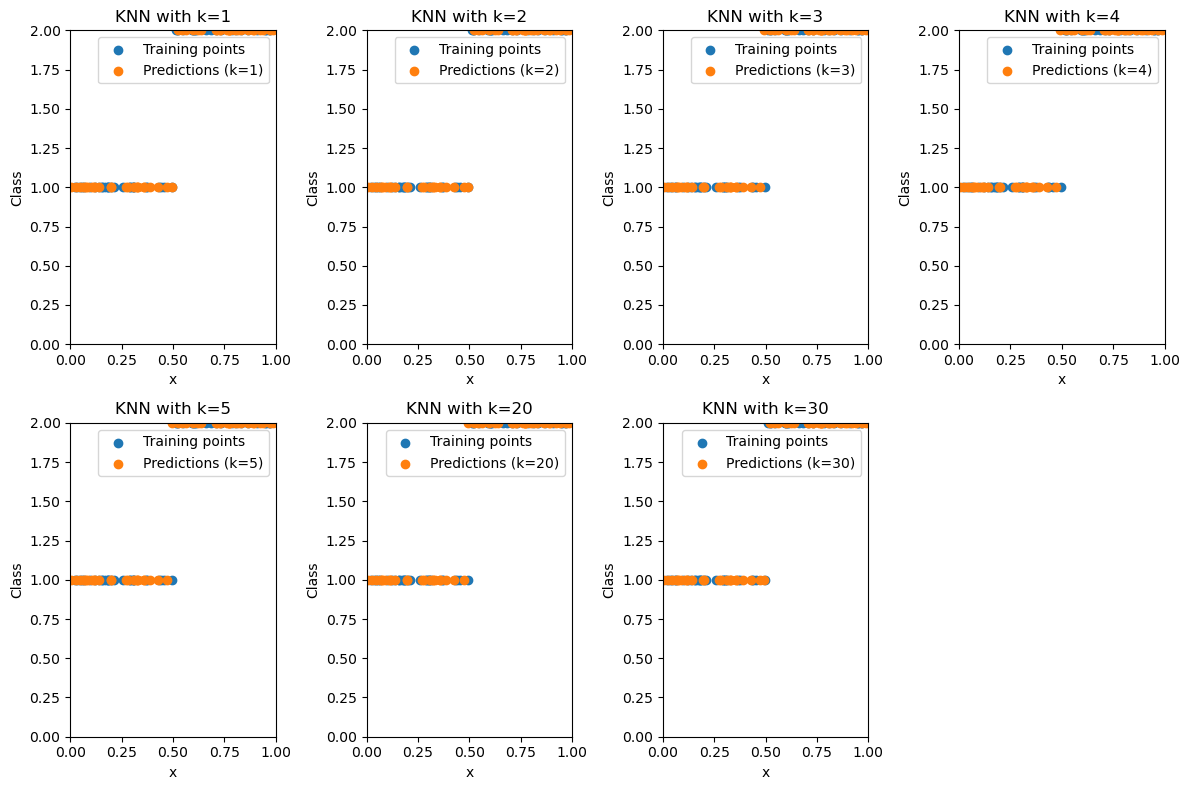

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Generate the data
np.random.seed(42)  # For reproducibility

X_train = np.random.rand(50, 1)  # Training features
y_train = np.array([1 if x <= 0.5 else 2 for x in X_train.ravel()])  # Labels

X_test = np.random.rand(50, 1)  # Test data

# Step 2: Function for KNN classification
def classify_knn(X_train, y_train, X_test, k_values):
    predictions = {}  # Store results

    # Loop over k values
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train, y_train)        # Train model
        y_pred = knn.predict(X_test)     # Predict
        predictions[k] = y_pred          # Store results

    return predictions

# Step 3: Run KNN for different k values
k_values = [1, 2, 3, 4, 5, 20, 30]
predictions = classify_knn(X_train, y_train, X_test, k_values)

# Step 4: Plot results
plt.figure(figsize=(12, 8))

for i, k in enumerate(k_values, 1):
    plt.subplot(2, 4, i)

    # Training points
    plt.scatter(X_train, y_train, label='Training points')

    # Predicted points
    plt.scatter(X_test, predictions[k], label=f'Predictions (k={k})')

    plt.title(f'KNN with k={k}')
    plt.xlabel('x')
    plt.ylabel('Class')
    plt.xlim(0, 1)
    plt.ylim(0, 2)
    plt.legend()

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Load dataset
try:
    df = pd.read_csv("KNNalgo.csv")
except FileNotFoundError:
    print("Error: 'KNNalgo.csv' not found")
    exit()

# Step 2: Handle missing values (important)
df = df.dropna()

# Step 3: Convert categorical labels to numeric (if needed)
if df.iloc[:, -1].dtype == 'object':
    df.iloc[:, -1] = pd.factorize(df.iloc[:, -1])[0]

# Step 4: Split into features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 5: Function for KNN classification
def classify_knn(X, y, k_values):
    predictions = {}

    for k in k_values:
        if k > len(X):
            continue

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        y_pred = knn.predict(X)
        predictions[k] = y_pred

    return predictions

# Step 6: Run KNN
k_values = [1, 2, 3, 4, 5, 20, 30]
predictions = classify_knn(X, y, k_values)

# Step 7: Plot results (uses first feature only)
plt.figure(figsize=(12, 8))

for i, k in enumerate(predictions.keys(), 1):
    plt.subplot(2, 4, i)

    # Use only first feature for visualization
    plt.scatter(X[:, 0], y, label='Actual')
    plt.scatter(X[:, 0], predictions[k], label=f'Predicted (k={k})')

    plt.title(f'KNN with k={k}')
    plt.xlabel('Feature 1')
    plt.ylabel('Class')
    plt.legend()

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Step 1: Load dataset
try:
    df = pd.read_csv("KNNalgo.csv")
except FileNotFoundError:
    print("Error: File not found")
    exit()

# Step 2: Remove missing values (important)
df = df.dropna()

# Step 3: Convert ALL categorical columns to numeric
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

# Step 4: Split features and labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Step 5: KNN function
def classify_knn(X, y, k_values):
    predictions = {}

    for k in k_values:
        if k > len(X):
            continue

        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y)
        y_pred = knn.predict(X)
        predictions[k] = y_pred

    return predictions

# Step 6: Run KNN
k_values = [1, 2, 3, 4, 5, 20, 30]
predictions = classify_knn(X, y, k_values)

# Step 7: Plot
plt.figure(figsize=(12, 8))

for i, k in enumerate(predictions.keys(), 1):
    plt.subplot(2, 4, i)

    plt.scatter(X[:, 0], y, label='Actual')
    plt.scatter(X[:, 0], predictions[k], label=f'Predicted (k={k})')

    plt.title(f'KNN (k={k})')
    plt.xlabel('Feature')
    plt.ylabel('Class')
    plt.legend()

plt.tight_layout()
plt.show()

<Figure size 1200x800 with 0 Axes>